# Compare alkali matrix elements with the UD atomic data portal

The [Portal for High-Precision Atomic Data and Computation](https://www1.udel.edu/atom/) (University of Delaware)
tabulates *reduced* E1 matrix elements directly in $e a_0$, each with an uncertainty,
computed with a linearized coupled-cluster (all-order) method.

Compared to the NIST ASD line strengths used in
[compare_nist_matrix_elements.ipynb](compare_nist_matrix_elements.ipynb),
this covers far more transitions and is much more accurate for the weak ones.
It therefore lets us test the core-polarization corrected ("dressed") electric-dipole operator

$$d(r) = r - \frac{\alpha_c}{r^2}\left(1 - e^{-(r/r_c)^3}\right)$$

on all five alkalis at once, and on transition series its cutoff $r_c$ was never fitted to.

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import rydstate
from rydstate.species.element_properties import get_element_properties

## The reference data

`udel_atom_portal_e1_matrix_elements.csv` next to this notebook holds the alkali subset retrieved from the portal:
3057 unique transitions for Li, Na, K, Rb and Cs, covering the $s$-$p$, $p$-$d$ and $d$-$f$ series
with principal quantum numbers up to $n \approx 14$.

The dressed operator is used automatically if `"electric_dipole"` is specified.
To compute the bare values for comparison, one can use `"electric_dipole_rydberg"` instead.

In [2]:
portal_file = Path("udel_atom_portal_e1_matrix_elements.csv")
with portal_file.open() as f:
    portal_rows = list(csv.DictReader(line for line in f if not line.startswith("#")))

max_relative_uncertainty = 0.05  # ignore reference values that are themselves uncertain

portal = {key: [] for key in ["species", "series", "n_max", "reference", "bare", "dressed"]}
for row in portal_rows:
    reference, uncertainty = float(row["matrix_element"]), float(row["uncertainty"])
    if uncertainty / reference > max_relative_uncertainty:
        continue
    state_1 = rydstate.RydbergStateSQDTAlkali(row["species"], int(row["n1"]), l=int(row["l1"]), j=float(row["j1"]))
    state_2 = rydstate.RydbergStateSQDTAlkali(row["species"], int(row["n2"]), l=int(row["l2"]), j=float(row["j2"]))
    l_low, l_high = sorted([int(row["l1"]), int(row["l2"])])
    portal["species"].append(row["species"])
    portal["series"].append(f"{'spdf'[l_low]}-{'spdf'[l_high]}")
    portal["n_max"].append(max(int(row["n1"]), int(row["n2"])))
    portal["reference"].append(reference)
    portal["bare"].append(abs(state_1.calc_reduced_matrix_element(state_2, "electric_dipole_rydberg", unit="e a0")))
    portal["dressed"].append(abs(state_1.calc_reduced_matrix_element(state_2, "electric_dipole", unit="e a0")))

portal = {key: np.array(value) for key, value in portal.items()}
ratio = {operator: portal[operator] / portal["reference"] for operator in ("bare", "dressed")}
# relative size of the core-polarization correction for each transition
correction = np.abs(portal["dressed"] / portal["bare"] - 1)

species_list = ["Li", "Na", "K", "Rb", "Cs"]
series_list = ["s-p", "p-d", "d-f"]
print(f"{len(portal['reference'])} transitions with a portal uncertainty below {max_relative_uncertainty:.0%}")
for species in species_list:
    element_properties = get_element_properties(species)
    counts = " ".join(
        f"{series}: {np.sum((portal['species'] == species) & (portal['series'] == series)):4d}"
        for series in series_list
    )
    print(
        f"  {species:2s}  alpha_cs_core = {element_properties.alpha_closed_shell_core:7.4f},"
        f" r_c = {element_properties.r_c_dipole_operator:.2f}   {counts}"
    )

2636 transitions with a portal uncertainty below 5%
  Li  alpha_cs_core =  0.1923, r_c = 3.04   s-p:  152 p-d:  216 d-f:  168
  Na  alpha_cs_core =  0.9448, r_c = 3.18   s-p:  162 p-d:  243 d-f:  216
  K   alpha_cs_core =  5.3310, r_c = 2.30   s-p:  148 p-d:  133 d-f:  183
  Rb  alpha_cs_core =  9.0760, r_c = 3.12   s-p:  148 p-d:  191 d-f:  159
  Cs  alpha_cs_core = 15.6440, r_c = 3.42   s-p:  148 p-d:  211 d-f:  158


## NIST ASD vs. the portal

The three Rb $5p \rightarrow 6d$ lines compared against NIST ASD in
[compare_nist_matrix_elements.ipynb](compare_nist_matrix_elements.ipynb) are also in the portal data,
which lets us check the two references against each other.

In [3]:
# {((n, j) lower, (n, j) upper): S in (e a0)^2} from NIST ASD, see compare_nist_matrix_elements.ipynb
nist_s_5p_6d = {
    ((5, 0.5), (6, 1.5)): 1.392,
    ((5, 1.5), (6, 2.5)): 2.749,
    ((5, 1.5), (6, 1.5)): 3.11e-1,
}

print(f"{'transition':>18} {'NIST ASD':>10} {'portal':>17} {'bare':>10} {'dressed':>10}")
for row in portal_rows:
    states = {(int(row["n1"]), int(row["l1"])), (int(row["n2"]), int(row["l2"]))}
    if row["species"] != "Rb" or states != {(5, 1), (6, 2)}:
        continue
    j_low, j_up = float(row["j1"]), float(row["j2"])
    state_low = rydstate.RydbergStateSQDTAlkali("Rb", 5, l=1, j=j_low)
    state_up = rydstate.RydbergStateSQDTAlkali("Rb", 6, l=2, j=j_up)
    transition = f"5p_{2 * j_low:1.0f}/2 -> 6d_{2 * j_up:1.0f}/2"
    print(
        f"{transition:>18} {np.sqrt(nist_s_5p_6d[((5, j_low), (6, j_up))]):10.4f}"
        f" {float(row['matrix_element']):10.4f} +- {float(row['uncertainty']):.4f}"
        f" {abs(state_up.calc_reduced_matrix_element(state_low, 'electric_dipole_rydberg', unit='e a0')):10.4f}"
        f" {abs(state_up.calc_reduced_matrix_element(state_low, 'electric_dipole', unit='e a0')):10.4f}"
    )

        transition   NIST ASD            portal       bare    dressed
  5p_1/2 -> 6d_3/2     1.1798     1.0674 +- 0.0372     1.0322     1.0830
  5p_3/2 -> 6d_3/2     0.5577     0.5064 +- 0.0167     0.4920     0.5135
  5p_3/2 -> 6d_5/2     1.6580     1.5116 +- 0.0484     1.4684     1.5332


## The correction only acts where it should

The core-polarization term matters only when the bare radial integral suffers a strong cancellation.
Grouping the transitions by how much the dressed operator changes the matrix element therefore separates
the transitions the correction is irrelevant for from the ones that actually test it.

In [4]:
correction_bins = [(0.0, 0.01), (0.01, 0.05), (0.05, 0.20), (0.20, np.inf)]

print(f"{'size of correction':>19} {'N':>5}   median (and worst) |calc / portal - 1|")
print(f"{'':>19} {'':>5}   {'bare':>16} {'dressed':>16}")
for low, high in correction_bins:
    mask = (correction >= low) & (correction < high)
    label = f"{low:.0%} - {high:.0%}" if np.isfinite(high) else f"above {low:.0%}"
    deviations = [np.abs(ratio[operator][mask] - 1) for operator in ("bare", "dressed")]
    columns = "".join(f"{np.median(d):8.2%} ({np.max(d):5.1%})" for d in deviations)
    print(f"{label:>19} {mask.sum():5d}   {columns}")

 size of correction     N   median (and worst) |calc / portal - 1|
                                        bare          dressed
            0% - 1%  2265      0.16% ( 6.4%)   0.15% ( 6.4%)
            1% - 5%   294      1.83% ( 6.6%)   0.89% ( 5.0%)
           5% - 20%    70      7.87% (25.6%)   2.65% ( 8.1%)
          above 20%     7     21.10% (46.0%)   4.52% (10.6%)


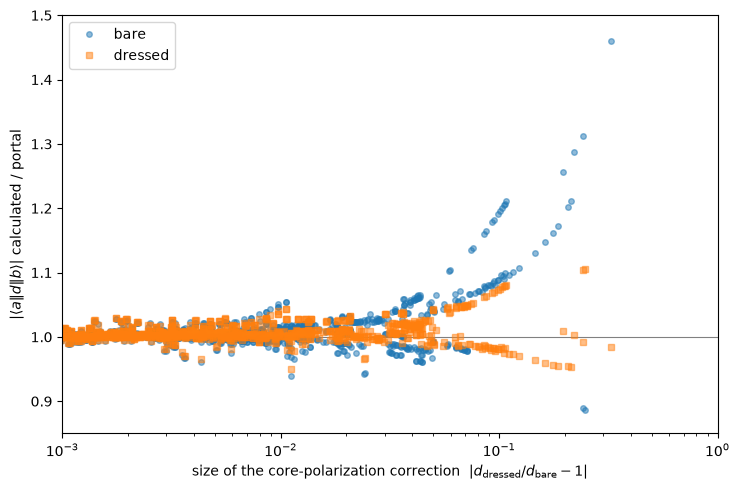

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5))

styles = {"bare": ("C0", "o"), "dressed": ("C1", "s")}
for operator, (color, marker) in styles.items():
    ax.plot(correction, ratio[operator], marker, color=color, markersize=4, linestyle="none", alpha=0.5, label=operator)

ax.axhline(1, color="gray", lw=0.8, zorder=-10)
ax.set_xscale("log")
ax.set_xlim(1e-3, 1)  # for the 1550 transitions with a smaller correction both operators agree to 0.1% (median)
ax.set_ylim(0.85, 1.5)
ax.set_xlabel(r"size of the core-polarization correction  $|d_\mathrm{dressed} / d_\mathrm{bare} - 1|$")
ax.set_ylabel(r"$|\langle a \Vert d \Vert b \rangle|$ calculated / portal")
ax.legend()

fig.tight_layout()
plt.show()

## Ratio per species and transition series

The aggregate view above hides which transitions the deviations belong to.
The plots below therefore show the ratio calculated / portal for each species separately,
with the three transition series colour coded and plotted against the principal quantum number
of the more excited state of each transition.

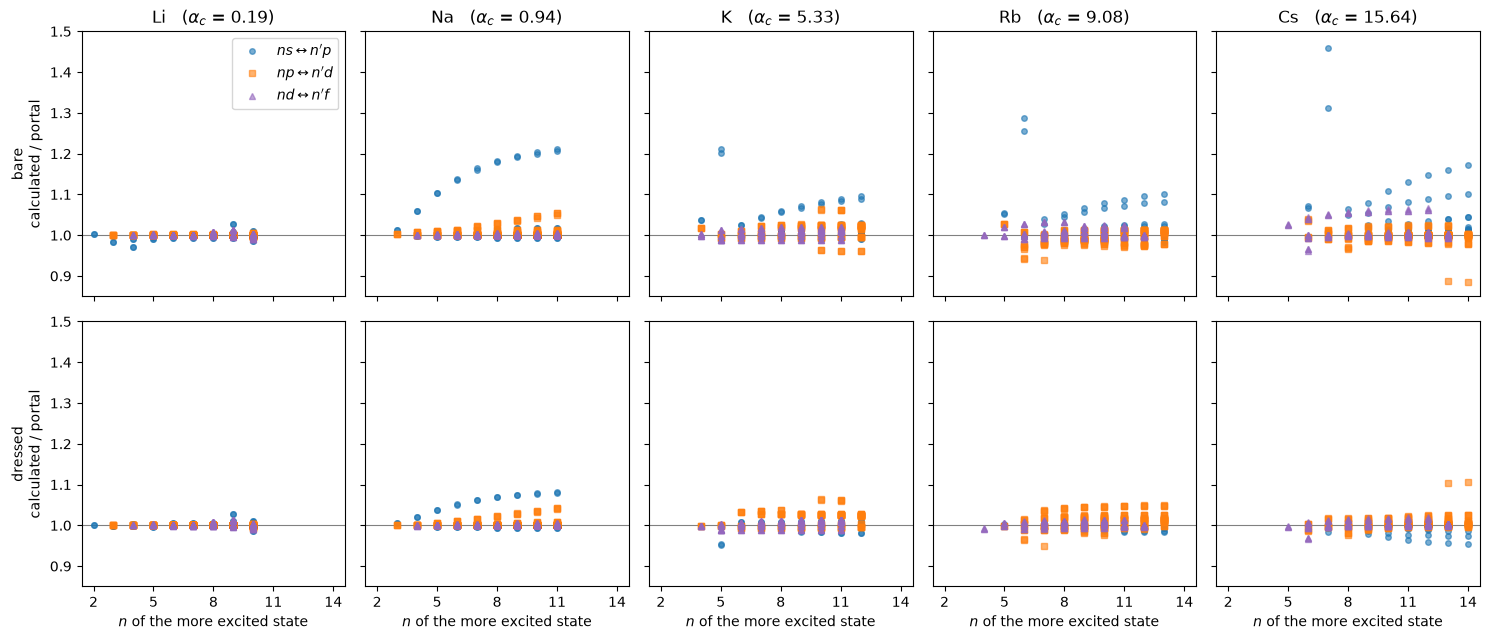

In [6]:
fig, axes = plt.subplots(2, len(species_list), figsize=(15, 6.5), sharex=True, sharey=True)

series_styles = {"s-p": ("C0", "o"), "p-d": ("C1", "s"), "d-f": ("C4", "^")}
series_labels = {
    "s-p": r"$ns \leftrightarrow n'p$",
    "p-d": r"$np \leftrightarrow n'd$",
    "d-f": r"$nd \leftrightarrow n'f$",
}

for column, species in enumerate(species_list):
    for row, operator in enumerate(styles):
        ax = axes[row, column]
        for series, (color, marker) in series_styles.items():
            mask = (portal["species"] == species) & (portal["series"] == series)
            ax.plot(
                portal["n_max"][mask],
                ratio[operator][mask],
                marker,
                color=color,
                markersize=4,
                linestyle="none",
                alpha=0.6,
                label=series_labels[series],
            )
        ax.axhline(1, color="gray", lw=0.8, zorder=-10)

for column, species in enumerate(species_list):
    alpha = get_element_properties(species).alpha_closed_shell_core
    axes[0, column].set_title(rf"{species}   ($\alpha_c$ = {alpha:.2f})")
    axes[-1, column].set_xlabel(r"$n$ of the more excited state")
    axes[-1, column].set_xticks(range(2, 15, 3))
for row, operator in enumerate(styles):
    axes[row, 0].set_ylabel(f"{operator}\ncalculated / portal")

axes[0, 0].set_ylim(0.85, 1.5)
axes[0, 0].legend()

fig.tight_layout()
plt.show()

What the panels show:

- **Li** ($\alpha_c = 0.19$): the correction is invisible on this scale, as it should be.
- The branch of $ns \leftrightarrow n'p$ points drifting upwards with $n$ in the bare row is in each case the
  principal series from the ground state, whose radial integral cancels more and more strongly with increasing $n$.
  This is where the bare operator fails worst (up to $+46\%$ for Cs), and the dressed operator removes most of it.
- The $np \leftrightarrow n'd$ and $nd \leftrightarrow n'f$ series stay within a few percent for both operators ---
  these states barely penetrate the core.
- A residual remains for the Na principal series ($+8\%$ at $n = 11$). Its $r_c$ was fitted to the NIST ASD line
  strengths of that very series, which are themselves less accurate than the portal values;
  a smaller $r_c \approx 2.4$ would reproduce the portal data for Na to about 2%.
- The two outliers at $n = 14$ in the dressed row for Cs are the very weak $5d_{3/2} \leftrightarrow np_{1/2}$ lines,
  where the integral almost vanishes, the portal uncertainty is itself 5%, and the correction overshoots.

## Per species

The fitted $r_c$ values were obtained from the principal series ($s$-$p$) of each species,
so the $p$-$d$ and $d$-$f$ transitions are an independent test.
Below we restrict to the transitions where the correction exceeds 1%, i.e. those that actually probe it.

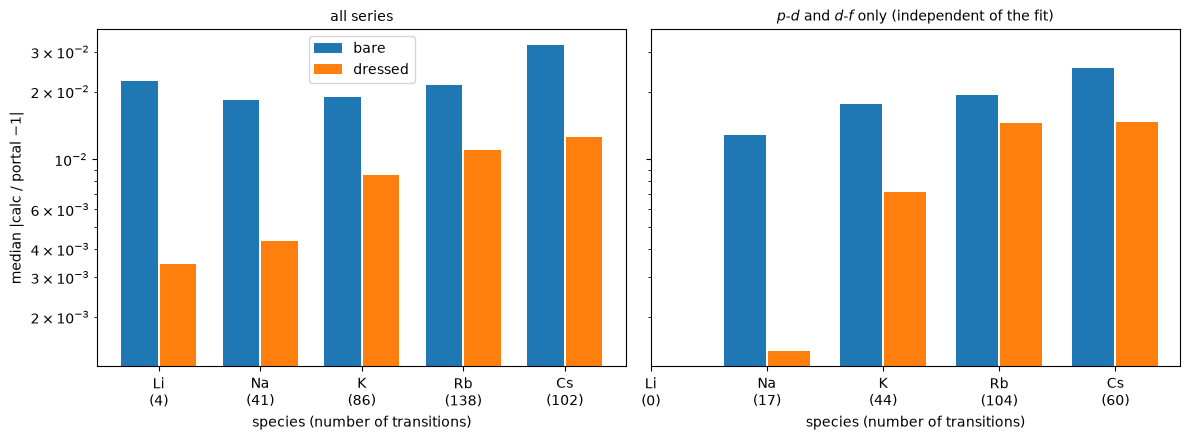

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
subsets = {
    "all series": correction > 0.01,
    "$p$-$d$ and $d$-$f$ only (independent of the fit)": (correction > 0.01) & (portal["series"] != "s-p"),
}

offsets = {"bare": -0.19, "dressed": +0.19}
for ax, (title, subset) in zip(axes, subsets.items(), strict=True):
    labels = []
    for i, species in enumerate(species_list):
        mask = subset & (portal["species"] == species)
        labels.append(f"{species}\n({mask.sum()})")
        for operator, (color, _marker) in styles.items():
            if not mask.any():
                continue
            median = np.median(np.abs(ratio[operator][mask] - 1))
            ax.bar(i + offsets[operator], median, width=0.36, color=color, label=operator if i == 0 else None)

    ax.set_xticks(range(len(species_list)), labels=labels)
    ax.set_title(title, fontsize=10)
    ax.set_yscale("log")

axes[0].set_ylabel(r"median $|$calc / portal $- 1|$")
axes[0].set_xlabel("species (number of transitions)")
axes[1].set_xlabel("species (number of transitions)")
axes[0].legend()

fig.tight_layout()
plt.show()

Wherever the core-polarization correction is relevant it moves the matrix elements towards the
high-precision reference, for every alkali and for series the cutoff radius was never fitted to.
The improvement is largest exactly where the bare operator fails worst: for the handful of transitions where the
correction exceeds 20% --- the $ns \rightarrow (n+1)p$ lines of K, Rb and Cs, whose radial integrals nearly cancel ---
the bare operator is off by up to 46%, the dressed one by at most about 10%.

For the vast majority of transitions the correction is below 1% and changes nothing;
in particular it never degrades the transitions it does not apply to.